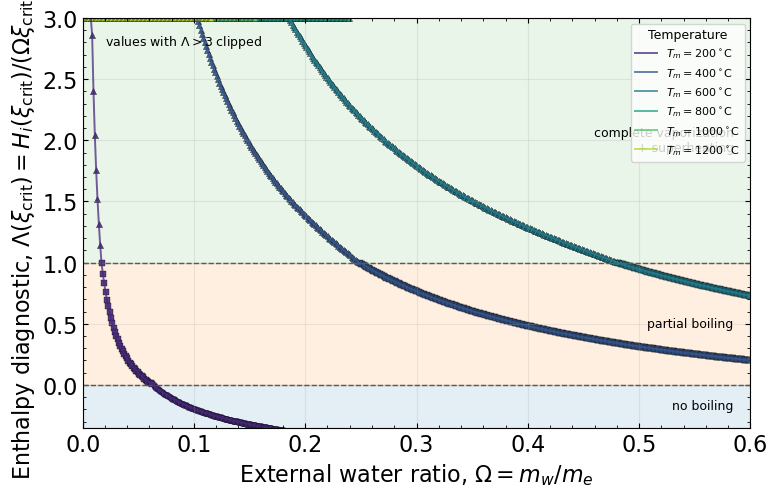

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# Parameters
# ============================================================

p = {
    "T_air": 273.15,
    "T_w0": 273.15,
    "T_sat": 373.15,
    "n": 0.03,
    "Cp_air": 1004.0,
    "Cp_m": 3000.0,
    "Cp_w": 1850.0,
    "Cp_l": 4180.0,
    "R_air": 287.0,
    "R_g": 461.5,
    "R_w": 461.5,
    "Lv": 2.5e6,
}

Tm_vals = np.array([473.15, 673.15, 873.15, 1073.15, 1273.15, 1473.15])

# Lambda is undefined at Omega = 0, so start slightly above zero.
Omega_vals = np.linspace(1.0e-4, 0.60, 500)


# ============================================================
# Thermodynamic helper functions
# ============================================================

def H_coeffs(Omega, Tm, p):
    """Return H0 and H1 such that H_i(xi) = H0 + H1 xi."""
    H0 = p["Cp_air"] * (p["T_air"] - p["T_sat"])

    H1 = (
        p["Cp_m"] * (Tm - p["T_sat"])
        - (1.0 + Omega) * p["Cp_air"] * (p["T_air"] - p["T_sat"])
        + Omega * p["Cp_l"] * (p["T_w0"] - p["T_sat"])
    )

    return H0, H1


def H_i(xi, Omega, Tm, p):
    H0, H1 = H_coeffs(Omega, Tm, p)
    return H0 + H1 * xi


def xi_max(Omega):
    return 1.0 / (1.0 + Omega)


def safe_div(num, den):
    if abs(den) < 1.0e-14:
        return np.nan
    return num / den


# ============================================================
# Candidate analytical thresholds
# ============================================================

def candidate_A(Omega, Tm, p):
    Rair = p["R_air"]
    Tair = p["T_air"]
    Cpa = p["Cp_air"]

    DeltaR_A = (1.0 + Omega) * p["R_air"] - p["n"] * p["R_g"]

    N_A1 = (
        p["Cp_m"] * Tm
        - (1.0 + Omega) * p["Cp_air"] * p["T_air"]
        + Omega * p["Cp_l"] * p["T_w0"]
    )

    D_A1 = (
        p["Cp_m"]
        - (1.0 + Omega) * p["Cp_air"]
        + Omega * p["Cp_l"]
    )

    a = -DeltaR_A * N_A1
    b = Rair * N_A1 - DeltaR_A * Cpa * Tair - Rair * Tair * D_A1

    return safe_div(-b, a)


def candidate_B(Omega, Tm, p):
    if Omega <= 0.0:
        return np.nan

    H0, H1 = H_coeffs(Omega, Tm, p)

    DeltaR_A = (1.0 + Omega) * p["R_air"] - p["n"] * p["R_g"]

    num = (
        p["R_air"] * (p["T_air"] - p["T_sat"])
        - (p["R_w"] / p["Lv"]) * H0 * p["T_sat"]
    )

    den = (
        -DeltaR_A
        + (p["R_w"] / p["Lv"]) * H1
    ) * p["T_sat"]

    return safe_div(num, den)


def candidate_C(Omega, Tm, p):
    Rair = p["R_air"]
    Tair = p["T_air"]
    Cpa = p["Cp_air"]

    H0, H1 = H_coeffs(Omega, Tm, p)

    DeltaR_C = (
        (1.0 + Omega) * p["R_air"]
        - p["n"] * p["R_g"]
        - Omega * p["R_w"]
    )

    D_C1 = (
        p["Cp_m"]
        - (1.0 + Omega) * p["Cp_air"]
        + Omega * p["Cp_w"]
    )

    S_C1 = p["T_sat"] * D_C1 + H1 - Omega * p["Lv"]

    a = -DeltaR_C * S_C1
    b = Rair * S_C1 - DeltaR_C * Cpa * Tair - Rair * Tair * D_C1

    return safe_div(-b, a)


# ============================================================
# Admissibility and selection
# ============================================================

def is_physical_xi(xi, Omega, tol=1.0e-10):
    return (
        np.isfinite(xi)
        and xi > tol
        and xi <= xi_max(Omega) + tol
    )


def admissible_candidates(Omega, Tm, p):
    """Return list of admissible candidates as (regime, xi)."""
    out = []

    xiA = candidate_A(Omega, Tm, p)
    xiB = candidate_B(Omega, Tm, p)
    xiC = candidate_C(Omega, Tm, p)

    # Regime A: no boiling
    if is_physical_xi(xiA, Omega):
        H = H_i(xiA, Omega, Tm, p)
        if H <= 0.0:
            out.append(("A", xiA))

    # Regime B: partial boiling
    if is_physical_xi(xiB, Omega):
        H = H_i(xiB, Omega, Tm, p)
        water_latent = Omega * xiB * p["Lv"]
        if 0.0 < H < water_latent:
            out.append(("B", xiB))

    # Regime C: complete vaporization + superheating
    if is_physical_xi(xiC, Omega):
        H = H_i(xiC, Omega, Tm, p)
        water_latent = Omega * xiC * p["Lv"]
        if H >= water_latent:
            out.append(("C", xiC))

    return out


def dry_reference_xi(Tm, p):
    """Dry reference threshold, using Omega = 0."""
    return candidate_A(0.0, Tm, p)


def select_threshold_curve(Omega_vals, Tm, p):
    """
    Select accepted threshold by continuity with the previous accepted xi.
    Initializes from the dry reference.
    """
    xi_sel = np.full_like(Omega_vals, np.nan, dtype=float)
    reg_sel = np.full(Omega_vals.shape, "", dtype=object)

    xi_ref = dry_reference_xi(Tm, p)

    for i, Omega in enumerate(Omega_vals):
        candidates = admissible_candidates(Omega, Tm, p)

        if len(candidates) == 0:
            continue

        # Choose candidate closest to the previous accepted threshold.
        regimes = [c[0] for c in candidates]
        xis = np.array([c[1] for c in candidates])

        j = np.nanargmin(np.abs(xis - xi_ref))

        reg_sel[i] = regimes[j]
        xi_sel[i] = xis[j]
        xi_ref = xi_sel[i]

    return xi_sel, reg_sel


def Lambda_at_threshold(xi, Omega, Tm, p):
    """Lambda = H_i / (Omega xi Lv). Undefined for dry case."""
    if (not np.isfinite(xi)) or Omega <= 0.0:
        return np.nan

    denom = Omega * xi * p["Lv"]

    if denom <= 0.0:
        return np.nan

    return H_i(xi, Omega, Tm, p) / denom


# ============================================================
# Compute curves
# ============================================================

results = {}

for Tm in Tm_vals:
    xi_curve, reg_curve = select_threshold_curve(Omega_vals, Tm, p)

    Lambda_curve = np.array([
        Lambda_at_threshold(xi, Omega, Tm, p)
        for xi, Omega in zip(xi_curve, Omega_vals)
    ])

    results[Tm] = {
        "Omega": Omega_vals,
        "xi": xi_curve,
        "regime": reg_curve,
        "Lambda": Lambda_curve,
    }

# ============================================================
# Plot Lambda diagnostic, capped for readability
# ============================================================

fig, ax = plt.subplots(figsize=(8.0, 5.2))

ymin = -0.35
ycap = 3.0

# Regime bands
ax.axhspan(ymin, 0.0, alpha=0.12, color="tab:blue")
ax.axhspan(0.0, 1.0, alpha=0.12, color="tab:orange")
ax.axhspan(1.0, ycap, alpha=0.10, color="tab:green")

# Regime boundaries
ax.axhline(0.0, color="0.35", linewidth=1.0, linestyle="--")
ax.axhline(1.0, color="0.35", linewidth=1.0, linestyle="--")

markers = {
    "A": "o",
    "B": "s",
    "C": "^",
}

colors = plt.cm.viridis(np.linspace(0.12, 0.88, len(Tm_vals)))

for color, Tm in zip(colors, Tm_vals):
    Omega = results[Tm]["Omega"]
    Lam = results[Tm]["Lambda"]
    regs = results[Tm]["regime"]

    valid = np.isfinite(Lam)

    # Cap Lambda only for plotting
    Lam_plot = np.copy(Lam)
    Lam_plot[Lam_plot > ycap] = ycap

    # Main line
    ax.plot(
        Omega[valid],
        Lam_plot[valid],
        color=color,
        linewidth=1.4,
        alpha=0.75,
   label=rf"$T_m={Tm-273.15:.0f}^\circ$C"
    )

    # Regime markers
    for reg, marker in markers.items():
        m = valid & (regs == reg)
        ax.scatter(
            Omega[m],
            Lam_plot[m],
            s=20,
            marker=marker,
            color=color,
            edgecolor="k",
            linewidth=0.25,
            alpha=0.9,
        )

# Label clipped values
ax.text(
    0.02, ycap - 0.12,
    r"values with $\Lambda>3$ clipped",
    ha="left",
    va="top",
    fontsize=9
)

# Regime labels
ax.text(
    0.585, -0.17,
    "no boiling",
    ha="right",
    va="center",
    fontsize=9,
)

ax.text(
    0.585, 0.50,
    "partial boiling",
    ha="right",
    va="center",
    fontsize=9,
)

ax.text(
    0.585, 2.0,
    "complete vaporization\n+ superheating",
    ha="right",
    va="center",
    fontsize=9,
)

ax.set_xlabel(r"External water ratio, $\Omega=m_w/m_e$")
ax.set_ylabel(
    r"Enthalpy diagnostic, "
    r"$\Lambda(\xi_{\rm crit})=H_i(\xi_{\rm crit})/(\Omega\xi_{\rm crit}L_v)$"
)

ax.set_xlim(0.0, 0.60)
ax.set_ylim(ymin, ycap)

# Temperature legend only; regime is already shown by bands + marker shapes
ax.legend(
    title="Temperature",
    loc="upper right",
    frameon=True,
    fontsize=8,
    title_fontsize=9,
)

ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig("lambda_regime_diagnostic_capped.png", dpi=300, bbox_inches="tight")
plt.show()

In [81]:
params = {
    'legend.title_fontsize': 'large',
    'axes.labelsize': 16,
    'font.size': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'text.usetex': False,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.top': True,
    'ytick.right': True,
    'figure.autolayout': True,
}
plt.rcParams.update(params)

# woh_iso = pd.read_csv("wohletz_isothermal.csv")
# woh_adi = pd.read_csv("wohletz_adiabatic.csv")


/var/folders/q2/2v_9qp1s1n9635tlzjm697gc0000gr/T/ipykernel_48127/1547812108.py:358: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig("wohletz_overlay_threshold.png", dpi=300, bbox_inches="tight")
/Users/carrile/anaconda3/envs/mohrfail/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


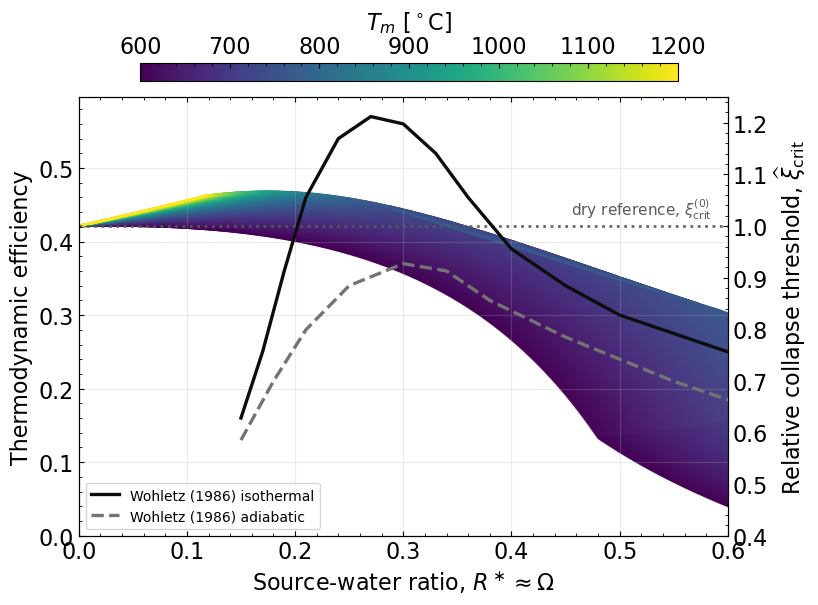

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Load digitized Wohletz curves
# ============================================================
# Expected files:
#   wohletz_fig2_isothermal_digitized.csv
#   wohletz_fig2_adiabatic_digitized.csv
#
# Expected columns:
#   Omega_or_Rstar, efficiency, curve
#
# In Wohletz, the x-axis is R* = m_water / m_magma.
# In the present model, this is compared with Omega = m_w / m_e.
woh_iso = pd.read_csv("wohletz_isothermal.csv")
woh_adi = pd.read_csv("wohletz_adiabatic.csv")

# Rename x column for cleaner plotting
woh_iso = woh_iso.rename(columns={"Omega_or_Rstar": "Rstar"})
woh_adi = woh_adi.rename(columns={"Omega_or_Rstar": "Rstar"})

# If your digitized efficiency is in percent, uncomment these:
# woh_iso["efficiency"] = woh_iso["efficiency"] / 100.0
# woh_adi["efficiency"] = woh_adi["efficiency"] / 100.0


# ============================================================
# 2. Analytical threshold model
# ============================================================

p = {
    "T_air": 273.15,
    "T_w0": 273.15,
    "T_sat": 373.15,
    "n": 0.03,
    "Cp_air": 1004.0,
    "Cp_m": 3000.0,
    "Cp_w": 1850.0,
    "Cp_l": 4180.0,
    "R_air": 287.0,
    "R_g": 461.5,
    "R_w": 461.5,
    "Lv": 2.5e6,
}

Tm_C_vals = np.linspace(600, 1200, 600)
Tm_vals = Tm_C_vals + 273.15
Omega_vals = np.linspace(1.0e-4, 0.60, 500)


def H_coeffs(Omega, Tm, p):
    H0 = p["Cp_air"] * (p["T_air"] - p["T_sat"])

    H1 = (
        p["Cp_m"] * (Tm - p["T_sat"])
        - (1.0 + Omega) * p["Cp_air"] * (p["T_air"] - p["T_sat"])
        + Omega * p["Cp_l"] * (p["T_w0"] - p["T_sat"])
    )

    return H0, H1


def H_i(xi, Omega, Tm, p):
    H0, H1 = H_coeffs(Omega, Tm, p)
    return H0 + H1 * xi


def xi_max(Omega):
    return 1.0 / (1.0 + Omega)


def safe_div(num, den):
    if abs(den) < 1.0e-14:
        return np.nan
    return num / den


def candidate_A(Omega, Tm, p):
    Rair = p["R_air"]
    Tair = p["T_air"]
    Cpa = p["Cp_air"]

    DeltaR_A = (1.0 + Omega) * p["R_air"] - p["n"] * p["R_g"]

    N_A1 = (
        p["Cp_m"] * Tm
        - (1.0 + Omega) * p["Cp_air"] * p["T_air"]
        + Omega * p["Cp_l"] * p["T_w0"]
    )

    D_A1 = (
        p["Cp_m"]
        - (1.0 + Omega) * p["Cp_air"]
        + Omega * p["Cp_l"]
    )

    a = -DeltaR_A * N_A1
    b = Rair * N_A1 - DeltaR_A * Cpa * Tair - Rair * Tair * D_A1

    return safe_div(-b, a)


def candidate_B(Omega, Tm, p):
    if Omega <= 0.0:
        return np.nan

    H0, H1 = H_coeffs(Omega, Tm, p)

    DeltaR_A = (1.0 + Omega) * p["R_air"] - p["n"] * p["R_g"]

    num = (
        p["R_air"] * (p["T_air"] - p["T_sat"])
        - (p["R_w"] / p["Lv"]) * H0 * p["T_sat"]
    )

    den = (
        -DeltaR_A
        + (p["R_w"] / p["Lv"]) * H1
    ) * p["T_sat"]

    return safe_div(num, den)


def candidate_C(Omega, Tm, p):
    Rair = p["R_air"]
    Tair = p["T_air"]
    Cpa = p["Cp_air"]

    H0, H1 = H_coeffs(Omega, Tm, p)

    DeltaR_C = (
        (1.0 + Omega) * p["R_air"]
        - p["n"] * p["R_g"]
        - Omega * p["R_w"]
    )

    D_C1 = (
        p["Cp_m"]
        - (1.0 + Omega) * p["Cp_air"]
        + Omega * p["Cp_w"]
    )

    S_C1 = p["T_sat"] * D_C1 + H1 - Omega * p["Lv"]

    a = -DeltaR_C * S_C1
    b = Rair * S_C1 - DeltaR_C * Cpa * Tair - Rair * Tair * D_C1

    return safe_div(-b, a)


def is_physical_xi(xi, Omega, tol=1.0e-10):
    return (
        np.isfinite(xi)
        and xi > tol
        and xi <= xi_max(Omega) + tol
    )


def admissible_candidates(Omega, Tm, p):
    out = []

    xiA = candidate_A(Omega, Tm, p)
    xiB = candidate_B(Omega, Tm, p)
    xiC = candidate_C(Omega, Tm, p)

    if is_physical_xi(xiA, Omega):
        H = H_i(xiA, Omega, Tm, p)
        if H <= 0.0:
            out.append(("A", xiA))

    if is_physical_xi(xiB, Omega):
        H = H_i(xiB, Omega, Tm, p)
        if 0.0 < H < Omega * xiB * p["Lv"]:
            out.append(("B", xiB))

    if is_physical_xi(xiC, Omega):
        H = H_i(xiC, Omega, Tm, p)
        if H >= Omega * xiC * p["Lv"]:
            out.append(("C", xiC))

    return out


def dry_reference_xi(Tm, p):
    return candidate_A(0.0, Tm, p)


def select_threshold_curve(Omega_vals, Tm, p):
    xi_sel = np.full_like(Omega_vals, np.nan, dtype=float)
    reg_sel = np.full(Omega_vals.shape, "", dtype=object)

    xi_ref = dry_reference_xi(Tm, p)

    for i, Omega in enumerate(Omega_vals):
        candidates = admissible_candidates(Omega, Tm, p)

        if len(candidates) == 0:
            continue

        regimes = [c[0] for c in candidates]
        xis = np.array([c[1] for c in candidates])

        j = np.nanargmin(np.abs(xis - xi_ref))

        reg_sel[i] = regimes[j]
        xi_sel[i] = xis[j]
        xi_ref = xi_sel[i]

    return xi_sel, reg_sel


# ============================================================
# 3. Compute normalized collapse threshold
# ============================================================

results = {}

for Tm_C, Tm in zip(Tm_C_vals, Tm_vals):
    xi_curve, reg_curve = select_threshold_curve(Omega_vals, Tm, p)
    xi_dry = dry_reference_xi(Tm, p)

    xi_hat = xi_curve / xi_dry

    results[Tm_C] = {
        "Omega": Omega_vals,
        "xi": xi_curve,
        "xi_hat": xi_hat,
        "regime": reg_curve,
        "xi_dry": xi_dry,
    }

# ============================================================
# 4. Single-panel comparison plot with two y-axes
# ============================================================

import matplotlib as mpl
from matplotlib.lines import Line2D

fig, ax_eff = plt.subplots(figsize=(8.4, 5.4))

# ------------------------------------------------------------
# Left y-axis: Wohletz thermodynamic efficiency
# ------------------------------------------------------------

line_iso, = ax_eff.plot(
    woh_iso["Rstar"],
    woh_iso["efficiency"],
    color="0.05",
    linewidth=2.4,
    label="Wohletz (1986) isothermal",
    zorder = 20
)

line_adi, = ax_eff.plot(
    woh_adi["Rstar"],
    woh_adi["efficiency"],
    color="0.45",
    linewidth=2.4,
    linestyle="--",
    label="Wohletz (1986) adiabatic",
    zorder = 19,
)

ax_eff.set_ylabel("Thermodynamic efficiency")
ax_eff.set_xlim(0.0, 0.60)
ax_eff.set_ylim(bottom=0.0)
ax_eff.grid(True, alpha=0.25)

# ------------------------------------------------------------
# Right y-axis: present normalized collapse threshold
# ------------------------------------------------------------

ax_thr = ax_eff.twinx()

# Put Wohletz axis above threshold axis
ax_eff.set_zorder(3)
ax_thr.set_zorder(2)

# Make the upper axis background transparent so it does not hide the other data
ax_eff.patch.set_visible(False)

norm = mpl.colors.Normalize(vmin=Tm_C_vals.min(), vmax=Tm_C_vals.max())
cmap = plt.cm.viridis
colors = cmap(norm(Tm_C_vals))

for color, Tm_C in zip(colors, Tm_C_vals):
    Omega = results[Tm_C]["Omega"]
    xi_hat = results[Tm_C]["xi_hat"]

    valid = np.isfinite(xi_hat)

    ax_thr.plot(
        Omega[valid],
        xi_hat[valid],
        color=color,
        linewidth=1.6,
        alpha=0.9
    )

ax_thr.axhline(
    1.0,
    color="0.35",
    linewidth=2.0,
    linestyle=":",
    alpha=0.9
)

ax_thr.set_ylabel(r"Relative collapse threshold, $\widehat{\xi}_{\rm crit}$")

# Set this based on your curve range
ax_thr.set_ylim(0.4, 1.25)

# ------------------------------------------------------------
# Shared x-axis
# ------------------------------------------------------------

ax_eff.set_xlabel(r"Source-water ratio, $R^\ast \approx \Omega$")
# Wohletz legend
ax_eff.legend(
    handles=[line_iso, line_adi],
    loc="lower left",
    frameon=True,
    fontsize=10
)

# Temperature colorbar for present-model curves, manually placed above plot
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig.subplots_adjust(top=0.84)

cax = fig.add_axes([0.18, 0.99, 0.64, 0.035])

cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation="horizontal"
)

cbar.set_label(r"$T_m$ [$^\circ$C]", labelpad=4)
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("top")

# Annotation for dry reference
ax_thr.text(
    0.585,
    1.01,
    r"dry reference, $\xi_{\mathrm{crit}}^{(0)}$",
    ha="right",
    va="bottom",
    fontsize=11,
    color="0.35"
)

fig.savefig("wohletz_overlay_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

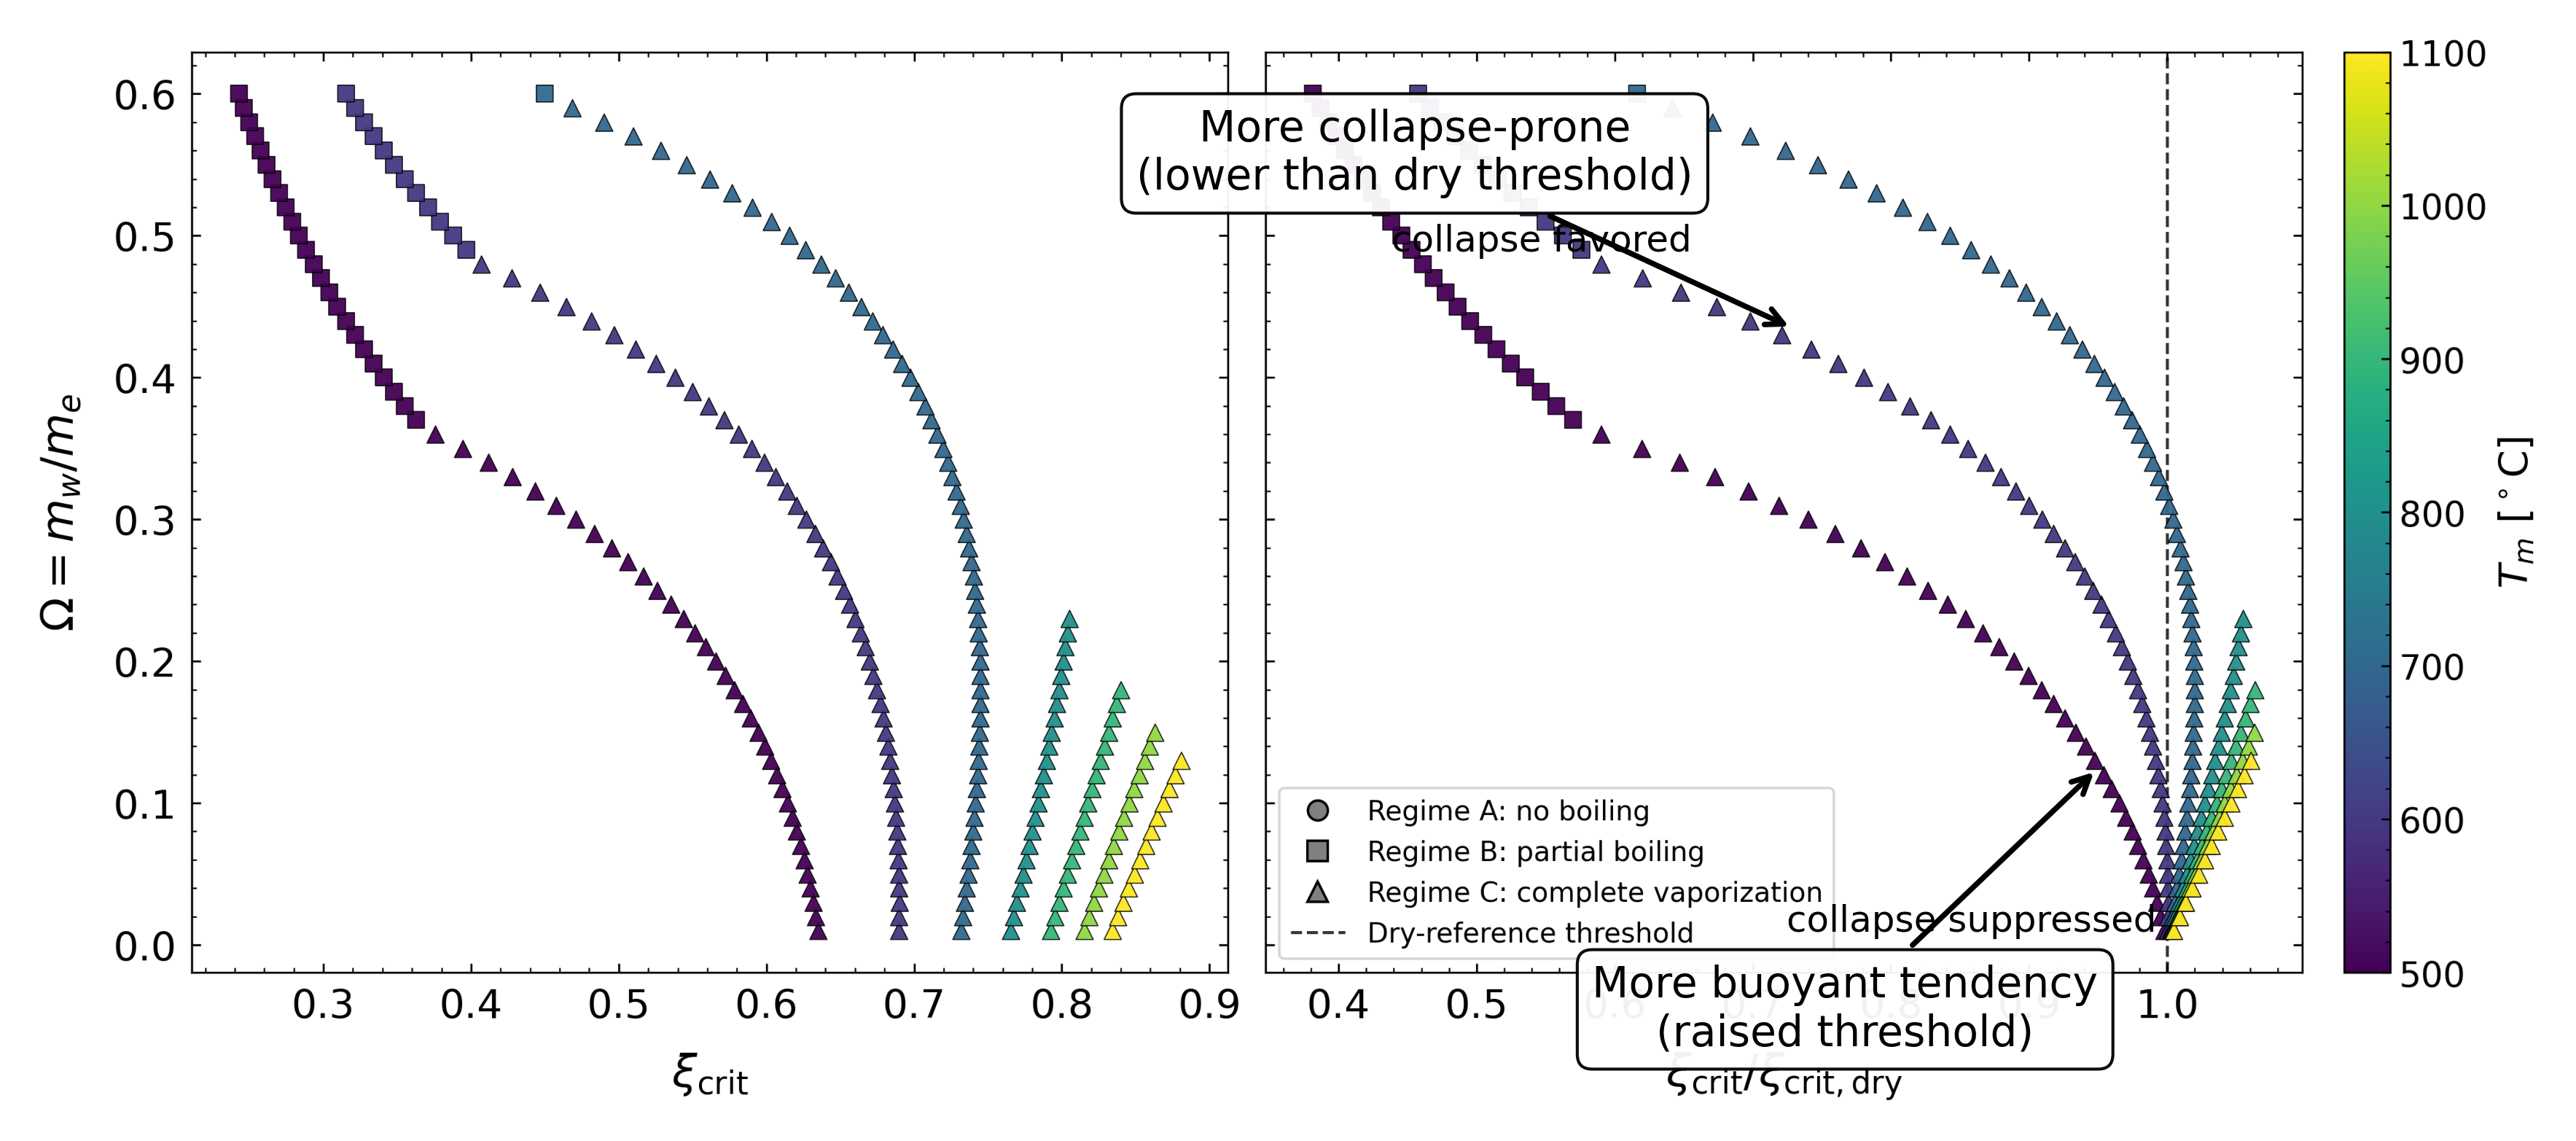

In [89]:
# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg

# # --------------------------------------------------
# # INPUT / OUTPUT
# # --------------------------------------------------
# input_png = "xi_and_xihat_by_temperature_regime_Omega.png"
# output_png = "xi_and_xihat_by_temperature_regime_Omega_annotated.png"

# # --------------------------------------------------
# # LOAD IMAGE
# # --------------------------------------------------
# img = mpimg.imread(input_png)

# fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
# ax.imshow(img)
# ax.axis("off")

# # --------------------------------------------------
# # ANNOTATIONS
# # All positions are in AXES FRACTION coordinates:
# # (0,0) = bottom-left of whole image
# # (1,1) = top-right of whole image
# # So you can tweak these by eye.
# # --------------------------------------------------

# # Top-left style annotation
# ax.annotate(
#     "More collapse-prone\n(lower than dry threshold)",
#     xy=(0.70, 0.72),        # arrow tip
#     xytext=(0.55, 0.88),    # text box location
#     xycoords="axes fraction",
#     textcoords="axes fraction",
#     ha="center",
#     va="center",
#     fontsize=14,
#     bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black", alpha=0.95),
#     arrowprops=dict(arrowstyle="->", lw=1.8, color="black")
# )

# # Bottom-right style annotation
# ax.annotate(
#     "More buoyant tendency\n(raised threshold)",
#     xy=(0.82, 0.32),        # arrow tip
#     xytext=(0.72, 0.10),    # text box location
#     xycoords="axes fraction",
#     textcoords="axes fraction",
#     ha="center",
#     va="center",
#     fontsize=14,
#     bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black", alpha=0.95),
#     arrowprops=dict(arrowstyle="->", lw=1.8, color="black")
# )

# # Optional little labels near the arrows
# ax.text(
#     0.60, 0.80,
#     "collapse favored",
#     transform=ax.transAxes,
#     fontsize=12,
#     ha="center",
#     va="center"
# )

# ax.text(
#     0.77, 0.18,
#     "collapse suppressed",
#     transform=ax.transAxes,
#     fontsize=12,
#     ha="center",
#     va="center"
# )
# 
# # --------------------------------------------------
# # SAVE
# # --------------------------------------------------
# plt.savefig(output_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
# plt.show()